In [31]:
import numpy as np
import skimage.transform
import astropy.io.fits as fits
import matplotlib.pyplot as plt
import os
import glob
import PIL.ImageDraw
import PIL.Image
%pylab inline --no-import-all
matplotlib.rcParams['image.origin'] = 'lower'
matplotlib.rcParams['image.interpolation'] = 'nearest'
matplotlib.rcParams['image.cmap'] = 'gray'

Populating the interactive namespace from numpy and matplotlib


## Dictionary to map labels to file names

In [32]:
#prim_key_map = {'hex1':'hex1', 'hex2':'hex2', 'hex3':'hex3', 'hex4':'hex4',
#                 'key24':'keystone24', 'pie08':'piewedge8', 'pie12':'piewedge12'}
#telap_dir = os.path.normpath('/astro/opticslab1/SCDA/Apertures/JPL/offset_masks')

In [33]:
prim_key_map = {'luvoir15m':'LUVOIR15m',
                'luvoir2017novAp01':'Aperture_1', 'luvoir2017novAp01c':'Aperture_1',
                'luvoir2017novAp02':'Aperture_2', 'luvoir2017novAp02c':'Aperture_2',
                'luvoir2017novAp03':'Aperture_3', 'luvoir2017novAp03c':'Aperture_3',
                'luvoir2017novAp04':'Aperture_4', 'luvoir2017novAp04c':'Aperture_4',
                'luvoir2017novAp05':'Aperture_5', 'luvoir2017novAp05c':'Aperture_5',
                'luvoir2017novAp05s':'Aperture_5', 'luvoir2017novAp05b':'Aperture_5',
                'luvoir2017novAp06':'Aperture_6', 'luvoir2017novAp06c':'Aperture_6',
                'luvoir2017novAp07':'Aperture_7', 'luvoir2017novAp07c':'Aperture_7',
                'luvoir2017novAp08':'Aperture_8', 'luvoir2017novAp08c':'Aperture_8',
                'luvoir2017novAp09':'Aperture_9', 'luvoir2017novAp09c':'Aperture_9',
                'luvoir2017novAp10':'Aperture_10', 'luvoir2017novAp10c':'Aperture_10',
                'luvoir2017novAp11':'Aperture_11', 'luvoir2017novAp11c':'Aperture_11'}

secobs_key_map = {'Cross':'cross', 'X':'x'}

#diameter of minimum square box enclosing the illuminated aperture
prim_D_box = {'luvoir2017novAp01':2048, 'luvoir2017novAp01c':2048,
              'luvoir2017novAp02':2048, 'luvoir2017novAp02c':2048,
              'luvoir2017novAp03':2048, 'luvoir2017novAp03c':2048,
              'luvoir2017novAp04':1814, 'luvoir2017novAp04c':1814,
              'luvoir2017novAp05':1900, 'luvoir2017novAp05c':1900,
              'luvoir2017novAp05s':1900, 'luvoir2017novAp05b':1900,
              'luvoir2017novAp06':1900, 'luvoir2017novAp06c':1900,
              'luvoir2017novAp07':1814, 'luvoir2017novAp07c':1814,
              'luvoir2017novAp08':2048, 'luvoir2017novAp08c':2048,
              'luvoir2017novAp09':2048, 'luvoir2017novAp09c':2048,
              'luvoir2017novAp10':1840, 'luvoir2017novAp10c':1840,
              'luvoir2017novAp11':1840, 'luvoir2017novAp11c':1840}

# Neil:
telap_dir = '/Users/kstlaurent/Documents/SCDA_2/input_files/LUVOIR Aperture Files'

# Kathryn:
#telap_dir = os.path.expanduser("/Users/kstlaurent/git/SCDA/LUVOIR Aperture Files")

## Set basic parameters

In [34]:
overwrite = False
N = 150/2 # pupil array quadrant width after binning
iD = 10
oD = 90 # _LS_OD_map = {'hex1':76, 'hex2':82, 'hex3':81, 'hex4':82, 'pie08':90,
aligntol = 2 # units of thousandths of pupil diameter
L = 2048 # starting array width

symm = 'full' # set to either 'quart' or 'half'
shape = 'ann' # set to 'ann' or 'hex' or a primary mirror key
prim_key = 'luvoir2017novAp05s'
edge = 'round' # set to 'gray' or 'round'

if prim_key in prim_D_box:
    D = prim_D_box[prim_key]
else:
    D = 2*N * (L//(2*N)) # starting pupil diameter (forced to be <= L)

In [35]:
LS_dir = os.path.abspath("/Users/kstlaurent/Documents/SCDA_2/input_files/lyot_stops")

if not os.path.exists(LS_dir):
    os.mkdir(LS_dir)
    print("created {:s} for LS arrays".format(LS_dir))
else:
    print("Destination {:s} already exists".format(LS_dir))

Destination /Users/kstlaurent/Documents/SCDA_2/input_files/lyot_stops already exists


## Define stop

In [36]:
inD = float(iD)/100
outD = float(oD)/100
xs = np.linspace(-L/2 + 0.5, L/2 - 0.5, L)
[Xs, Ys] = np.meshgrid(xs, xs)

if shape is 'hex':
    xycent = (L/2-0.5,L/2-0.5)
    hexagon_obj = matplotlib.patches.RegularPolygon(xycent,6,radius=outD*D/2/np.cos(np.pi/6))
    hexagon_verts = hexagon_obj.get_verts()
    hexagon_img = PIL.Image.new('L', (L,L), 0)
    PIL.ImageDraw.Draw(hexagon_img).polygon(list(hexagon_verts.ravel()), outline=1, fill=1)
    hexagon_mask = np.array(hexagon_img)
    Lyot_stop = hexagon_mask
    inside_ann = np.less_equal(Xs**2 + Ys**2, (inD*D/2)**2)
    Lyot_stop[inside_ann] = 0.
elif shape in prim_key_map: # Lyot stop with outer edge tracing the aperture perimeter 
    # Numerically erase the segment gaps
    if shape == 'luvoir15m':
        prim_fname = os.path.join(telap_dir, "{0:s}_{1:04d}pix.fits".format(prim_key_map[shape], D))
    elif 'luvoir2017nov' in shape:
        prim_fname = os.path.join(telap_dir, "{0:s}.fits".format(prim_key_map[shape]))
    else:
        prim_fname = os.path.join(telap_dir, "{0:s}_{1:04d}pix_offset_no_central_obsc.fits".format(
                                              prim_key_map[shape], D))
    prim = fits.getdata(prim_fname)
    
    max_shift = 1e-6
    shift_range = np.linspace(-max_shift,max_shift,3)
    [Xshifts, Yshifts] = np.meshgrid(shift_range, shift_range)
    allowed_shifts = np.less_equal(Xshifts**2 + Yshifts**2, max_shift**2)
    XYshifts_allowed = zip(Xshifts[allowed_shifts], Yshifts[allowed_shifts])
    nogap_prim = np.zeros(prim.shape)
    for (xshift,yshift) in XYshifts_allowed:
        shift = skimage.transform.SimilarityTransform(translation=(xshift,yshift))
        prim_shifted = skimage.transform.warp(prim, shift, order=1)
        nogap_prim = np.logical_or(nogap_prim, prim_shifted)
    perim = np.ndarray.astype(nogap_prim, np.float)
    
    if shape.endswith(('c','s','b')):
        # circular stop
        outside_ann = np.greater_equal(Xs**2 + Ys**2, (outD*D/2)**2)
        outer_stop = np.ones_like(prim)
        outer_stop[outside_ann] = 0.
        padded_perim = outer_stop.copy()
    else:
        
        # Define the undersized stop outer edge based on a shift-and-multiply padding loop
        w = D*(1. - outD)/2
        XYshifts_allowed = [(-w,0), (+w,0),
                            (+w*np.sin(np.pi/6),+w*np.cos(np.pi/6)), (-w*np.sin(np.pi/6),+w*np.cos(np.pi/6)),
                            (+w*np.sin(np.pi/6),-w*np.cos(np.pi/6)), (-w*np.sin(np.pi/6),-w*np.cos(np.pi/6))]
        padded_perim = np.ones(perim.shape)
        for (xshift,yshift) in XYshifts_allowed:
            shift = skimage.transform.SimilarityTransform(translation=(xshift,yshift))
            perim_shifted = skimage.transform.warp(perim, shift, order=1)
            padded_perim *= perim_shifted
        # Reset inner region to 1 in order to offer a "blank slate" for the inner padding array
        clear_inside = np.less_equal(Xs**2 + Ys**2, (0.5*D/2)**2)
        padded_perim[clear_inside] = 1
    
    # inner aperture padding, computed separately
    w = D*inD/2
    XYshifts_allowed = [(-w,0), (+w,0),
                        (+w*np.sin(np.pi/6),+w*np.cos(np.pi/6)), (-w*np.sin(np.pi/6),+w*np.cos(np.pi/6)),
                        (+w*np.sin(np.pi/6),-w*np.cos(np.pi/6)), (-w*np.sin(np.pi/6),-w*np.cos(np.pi/6))]
    padded_inner = np.ones(perim.shape)
    for (xshift,yshift) in XYshifts_allowed:
        shift = skimage.transform.SimilarityTransform(translation=(xshift,yshift))
        perim_shifted = skimage.transform.warp(perim, shift, order=1)
        padded_inner *= perim_shifted
        
    # Reset inner region to 1 in order to offer a "blank slate" for the inner padding array
    clear_outside = np.greater_equal(Xs**2 + Ys**2, (0.5*D/2)**2)
    padded_inner[clear_outside] = 1
    
    Lyot_stop = padded_perim.copy()
    Lyot_stop *= padded_inner
    
    # define inner, circular edge
    #inside_ann = np.less_equal(Xs**2 + Ys**2, (inD*D/2)**2)
    #Lyot_stop[inside_ann] = 0.
    plt.figure(figsize=(8,8))
    plt.imshow(Lyot_stop - perim)
    plt.figure(figsize=(8,8))
    plt.imshow(Lyot_stop)
else:
    inside_ann = np.less_equal(Xs**2 + Ys**2, (inD*D/2)**2)
    outside_ann = np.greater_equal(Xs**2 + Ys**2, (outD*D/2)**2)
    Lyot_stop = np.ones((L,L))
    Lyot_stop[inside_ann] = 0.
    Lyot_stop[outside_ann] = 0.
    

In [37]:
Lyot_stop.shape

(2048, 2048)

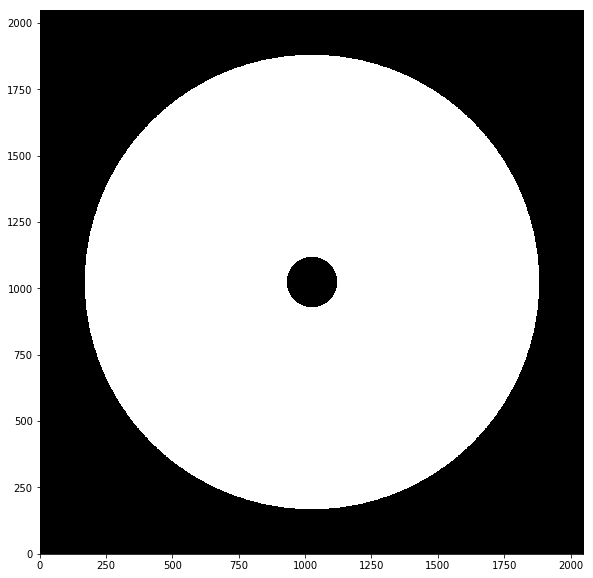

In [38]:
plt.figure(figsize=(10,10))
plt.imshow(Lyot_stop)

## Bin to final array resolution, crop

In [39]:
#scalefac = float(N)/(D/2)
#Lyot_stop_binned = skimage.transform.rescale(Lyot_stop, scalefac, order=1)

In [40]:
N_orig = D/2

if N_orig % N == 0:
    scalefac = N_orig // N
    print("Binning the original LS array {0:d}x".format(scalefac))
    Lyot_stop_binned = np.reshape(Lyot_stop, (Lyot_stop.shape[0]/scalefac, scalefac, 
                                              Lyot_stop.shape[1]/scalefac, scalefac)).mean(1).mean(2)
else:
    scalefac = float(N_orig) / N
    print("Binning the original LS array {0:.3f}x".format(scalefac))
    Lyot_stop_binned = skimage.transform.rescale(Lyot_stop, 1./scalefac, order=1)  

L_bin = Lyot_stop_binned.shape[0]

Binning the original LS array 12.667x


In [41]:
#N_orig = D/2
#Lyot_stop_crop = Lyot_stop[L/2-N_orig:L/2+N_orig,L/2-N_orig:L/2+N_orig]
#scalefac = int(N_orig/N)
#print("Binning the original LS array {0:d}x".format(scalefac))
#Lyot_stop_binned = np.reshape(Lyot_stop_crop, (Lyot_stop_crop.shape[0]/scalefac, scalefac, 
#                                               Lyot_stop_crop.shape[1]/scalefac, scalefac)).mean(1).mean(2)

In [42]:
Lyot_stop.shape

(2048, 2048)

In [43]:
Lyot_stop_binned.shape

(162, 162)

In [44]:
L_bin = Lyot_stop_binned.shape[0]
if symm is 'half':
    Lyot_stop_binned_crop = Lyot_stop_binned[L_bin//2-N:L_bin//2+N,L_bin//2:L_bin//2+N]
    Lyot_stop_binned_crop_binary = np.round(Lyot_stop_binned_crop).astype(int)
    print Lyot_stop_binned_crop.shape
elif symm is 'full':
    Lyot_stop_binned_crop = Lyot_stop_binned[L_bin//2-N:L_bin//2+N,L_bin//2-N:L_bin//2+N]
    Lyot_stop_binned_crop_binary = np.round(Lyot_stop_binned_crop).astype(int)
    print Lyot_stop_binned_crop.shape    
else:
    Lyot_stop_binned_crop = Lyot_stop_binned[L_bin//2:L_bin//2+N,L_bin//2:L_bin//2+N]
    Lyot_stop_binned_crop_binary = np.round(Lyot_stop_binned_crop).astype(int)
    print Lyot_stop_binned_crop.shape

(150, 150)


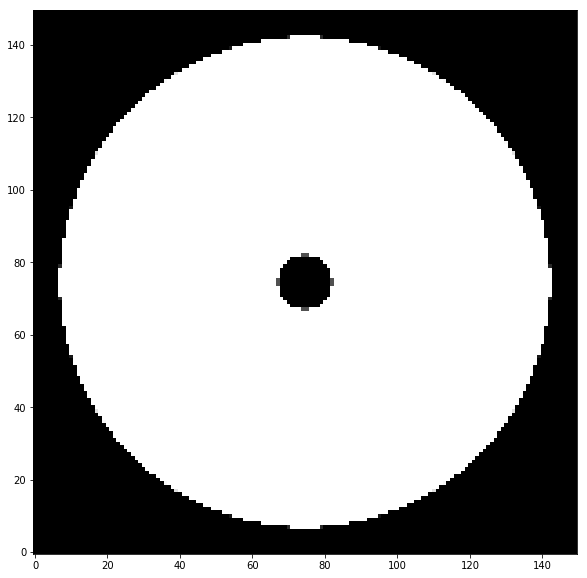

In [45]:
if symm is 'half':
    plt.figure(figsize=(20,10))
    #plt.imshow(Lyot_stop_binned_crop_binary)
    plt.imshow(Lyot_stop_binned_crop)   
else:
    plt.figure(figsize=(10,10))
    plt.imshow(Lyot_stop_binned_crop)
    #plt.imshow(Lyot_stop_binned_crop_binary)

## Write the binned, cropped Lyot stop to a fits file 

In [46]:
#if symm is 'half':
#    if shape in ['ann', 'hex']:
#        LS_dat_fname_tail = "LS_half_{0:s}{1:02d}D{2:02d}_clear_N{3:04d}.dat".format(
#                             shape, int(round(100*inD)), int(round(100*outD)), N)
#    else:
#        LS_dat_fname_tail = "LS_half_{0:s}P{1:02d}D{2:02d}_clear_N{3:04d}.dat".format(
#                             shape, int(round(100*inD)), int(round(100*outD)), N)
#else:
#    if shape in ['ann', 'hex']:
#        LS_dat_fname_tail = "LS_quart_{0:s}{1:02d}D{2:02d}_clear_N{3:04d}.dat".format(
#                             shape, int(round(100*inD)), int(round(100*outD)), N)
#    else:
#        LS_dat_fname_tail = "LS_quart_{0:s}P{1:02d}D{2:02d}_clear_N{3:04d}.dat".format(
#                             shape, int(round(100*inD)), int(round(100*outD)), N)
        
#LS_dat_fname = os.path.join(LS_dir, LS_dat_fname_tail)

#if not os.path.exists(LS_dat_fname) or overwrite==True:
#    if edge is 'gray':
#        np.savetxt(LS_dat_fname, Lyot_stop_binned_crop, fmt='%.6f', delimiter=" ")
#    else: # store version rounded to binary integers
#        np.savetxt(LS_dat_fname, Lyot_stop_binned_crop_binary, fmt='%d', delimiter=" ")
#    print("Wrote binned, cropped LS array to {0:s}".format(LS_dat_fname))
#else:
#    print("LS array {0:s} already exists, will not overwrite".format(LS_dat_fname))

In [47]:
LS_fits_fname_tail = "luvoir_LS_{0:s}{1:02d}D{2:02d}_clear_N{3:04d}.fits".format(shape, int(round(100*inD)), int(round(100*outD)), N*2)
LS_fits_fname = os.path.join(LS_dir, LS_fits_fname_tail)

if not os.path.exists(LS_fits_fname) or overwrite==True:
    if edge is 'gray':
        fits.writeto(LS_fits_fname, Lyot_stop_binned_crop,overwrite=True)
    else: # store version rounded to binary integers
        fits.writeto(LS_fits_fname, Lyot_stop_binned_crop_binary,overwrite=True)
    print("Wrote binned, cropped LS array to {0:s}".format(LS_fits_fname))
else:
    print("LS array {0:s} already exists, will not overwrite".format(LS_fits_fname))

Wrote binned, cropped LS array to /Users/kstlaurent/Documents/SCDA_2/input_files/lyot_stops/luvoir_LS_ann10D90_clear_N0150.fits


In [48]:
#if os.path.exists(LS_dat_fname): os.remove(LS_dat_fname)

In [49]:
prim_fname = "/Users/kstlaurent/Documents/SCDA_2/input_files/apertures/TelAp_full_luvoir2017novAp05ss100cobs1gap2_N{0:04d}.fits".format(N*2)
Aperture_binned_round = fits.getdata(prim_fname)

IOError: [Errno 2] No such file or directory: '/Users/kstlaurent/Documents/SCDA_2/input_files/apertures/TelAp_full_luvoir2017novAp05ss100cobs1gap2_N0150.fits'

In [ ]:
plt.figure(figsize=(30,30))
plt.imshow(Aperture_binned_round+Lyot_stop_binned_crop_binary)